# PHY408 Final Project — Measuring *g* via the Bouncing-Ball Method

**Method 2: Bouncing Ball (Microphone).** A hard ball is dropped from a
measured height $h_0$ onto a hard surface near the phone microphone.
The audio trace is used to extract the inter-bounce time intervals
$\Delta t_n$. Assuming a constant coefficient of restitution $e$ between
bounces,

$$\Delta t_n = A\,e^{n}, \qquad A = 2\sqrt{\frac{2h_0}{g}}$$

so that

$$\ln(\Delta t_n) = n\ln(e) + \ln A$$

is linear in $n$. Fitting this line gives the intercept $\ln A$, from which

$$g = \frac{8 h_0}{A^2}$$

Repeating at several drop heights $h_0$ gives independent estimates of $g$
that are combined with a PDG-style inverse-variance weighted average.

This notebook is organised as: **(1)** noise-floor characterisation from a
background recording, **(2)** the per-trial processing pipeline (ingestion →
cleaning → bounce detection → fit → $g$), **(3)** support for both phyphox
recording modes (Audio Amplitude / Audio Scope), **(4)** automatic
segmentation of multi-drop recordings, **(5)** pipeline validation against
synthetic data with known ground truth, **(6)** a template for real trial
results, and **(7)** the uncertainty budget.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import io_utils
import cleaning
import noise_characterization as noise
import bounce_detection as bd
import segmentation
import fitting
import synthetic_demo
from pipeline import process_trial, process_multi_drop_recording

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11


## 1. Noise-floor characterisation

Before any drop trial, a 10-minute background recording was taken in the
same room with the phone in the same position, using phyphox's **Audio
Amplitude** tool (sound pressure level in dB, sampled at an average
interval of ~120 ms — an envelope measurement, not the raw waveform).
This establishes (a) the ambient noise floor, used to set a bounce-detection
threshold with a safety margin, and (b) the actual sampling interval
statistics, which set a hard limit on how many late-time (fast) bounces can
be resolved.

### 1a. Data cleaning: trimming handling noise

Starting and stopping a phyphox recording means reaching for the phone,
tapping the screen, and moving around the lab — this contaminates the first
and last several seconds of *every* recording (background and trial alike)
with handling/footstep noise that is not part of the room's ambient floor.
The raw trace is inspected below to size that window, then a fixed trim is
applied and justified quantitatively via the before/after comparison and
retention rate (as the rubric's Data Cleaning criterion requires).


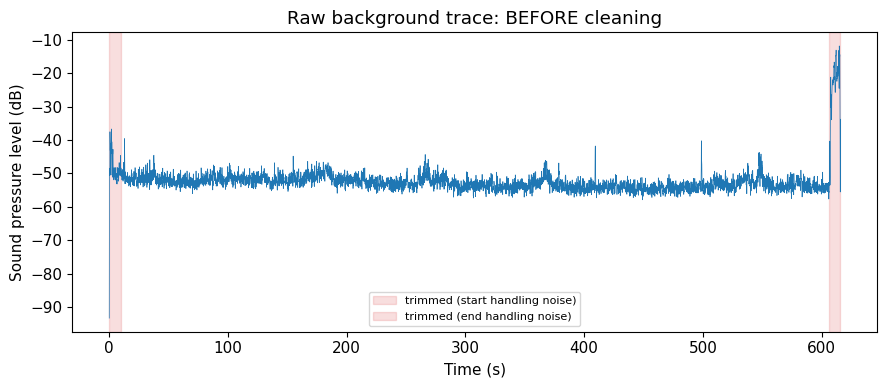

In [2]:
bg_raw = io_utils.load_audio_amplitude("../data/raw/background_noise.xls")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bg_raw["time_s"], bg_raw["spl_db"], lw=0.5)
ax.axvspan(0, 10, color="C3", alpha=0.15, label="trimmed (start handling noise)")
ax.axvspan(bg_raw["time_s"].max() - 10, bg_raw["time_s"].max(), color="C3", alpha=0.15,
           label="trimmed (end handling noise)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Sound pressure level (dB)")
ax.set_title("Raw background trace: BEFORE cleaning")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/background_before_cleaning.png", dpi=150)
plt.show()


In [3]:
bg, clean_report = cleaning.trim_and_clean(bg_raw, trim_start_s=10.0, trim_end_s=10.0)
print(cleaning.cleaning_summary_text(clean_report))


Trimmed first 10 s and last 10 s (handling noise); dropped 0 NaN samples.
Retained 4827 / 4991 samples (96.7%).


In [4]:
profile = noise.characterise(bg, k_sigma=5.0)
print(noise.summary_text(profile))


Samples: 4827 (NaN at start: 0)
Noise floor: mean = -52.79 dB, std = 1.98 dB, median = -52.92 dB, 95th pct = -49.40 dB, max transient = -39.54 dB
Sampling interval: mean = 123.4 ms, median = 122.9 ms, std = 6.1 ms, range = [102.3, 152.4] ms
Recommended bounce-detection threshold: -42.88 dB (mean + k*std)


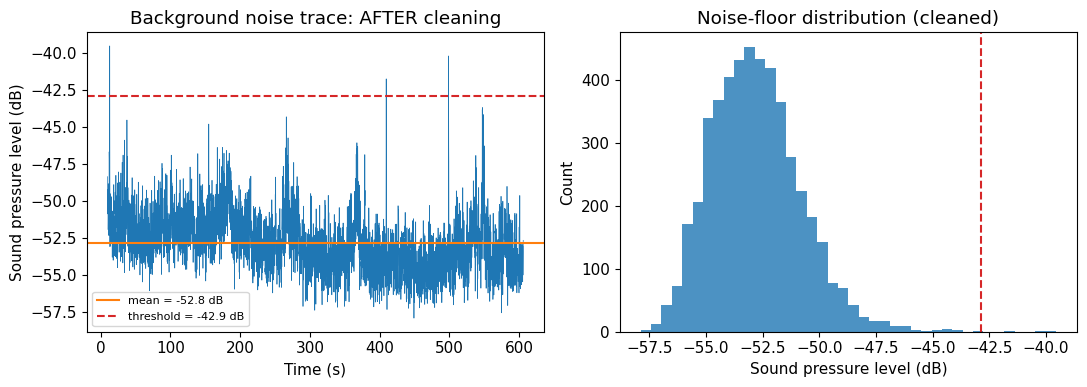

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(bg["time_s"], bg["spl_db"], lw=0.5)
axes[0].axhline(profile.mean_db, color="C1", label=f"mean = {profile.mean_db:.1f} dB")
axes[0].axhline(profile.recommended_threshold_db, color="C3", ls="--",
                label=f"threshold = {profile.recommended_threshold_db:.1f} dB")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Sound pressure level (dB)")
axes[0].set_title("Background noise trace: AFTER cleaning")
axes[0].legend(fontsize=8)

axes[1].hist(bg["spl_db"].dropna(), bins=40, color="C0", alpha=0.8)
axes[1].axvline(profile.recommended_threshold_db, color="C3", ls="--")
axes[1].set_xlabel("Sound pressure level (dB)")
axes[1].set_ylabel("Count")
axes[1].set_title("Noise-floor distribution (cleaned)")

plt.tight_layout()
plt.savefig("../figures/noise_floor.png", dpi=150)
plt.show()


**Note for real trial recordings:** a blanket 10 s trim is appropriate for
this long background recording but would delete real bounce data from a
short drop trial. The data-collection protocol instead asks for >= 2 s of
stationary silence at the start and end of each trial recording, so a
short, fixed trim (e.g. 1.5 s each side — see `process_trial`'s
`trim_start_s`/`trim_end_s` arguments) removes handling noise without
touching the bounce sequence itself.


### Temporal resolution limit (key experimental-design consideration)

The Audio Amplitude sampling interval (~120 ms typical, but with jitter down
to ~24 ms — see `min_dt_s` above) sets a Nyquist-like floor on which
inter-bounce intervals can be resolved without aliasing. For a ball with
coefficient of restitution $e$ dropped from $h_0$, $\Delta t_n = A e^n$
shrinks geometrically, so late bounces will eventually fall below this
floor and must be excluded from the fit rather than trusted. The cell below
estimates, for representative $(h_0, e)$, how many bounces are usable.


In [6]:
for h0_demo, e_demo in [(0.5, 0.75), (1.0, 0.8), (1.5, 0.85)]:
    A_demo = 2 * np.sqrt(2 * h0_demo / 9.783)
    n_max = noise.resolvable_bounce_count(profile, A_demo, e_demo, nyquist_factor=2.0)
    print(f"h0={h0_demo} m, e={e_demo}: A={A_demo:.3f} s, "
          f"usable bounces before aliasing risk: n <= {n_max}")


h0=0.5 m, e=0.75: A=0.639 s, usable bounces before aliasing risk: n <= 3
h0=1.0 m, e=0.8: A=0.904 s, usable bounces before aliasing risk: n <= 5
h0=1.5 m, e=0.85: A=1.108 s, usable bounces before aliasing risk: n <= 9


**Design implication:** only the first few bounces (roughly $n \le 4$–$6$
depending on height and restitution) should be trusted from Audio Amplitude
mode; later points should either be dropped from the fit or flagged with
inflated uncertainty. Section 3 below adds support for phyphox's raw
**Audio Scope** recording mode, which removes this limitation at the cost
of a heavier peak-detection step. This trade-off is discussed in the
report's Motivation/Experimental Design section.


## 2. Per-trial processing pipeline

`process_trial()` (imported from `src/pipeline.py`) takes one raw trial
recording (one drop height) and returns the fitted line, the extracted
$g$, and diagnostic plots. It is written once and reused identically for
every height — the same threshold and detection logic that was validated
against the background noise above. See `src/pipeline.py` for the full
implementation and docstrings (also used, unchanged, by
`notebooks/real_data_analysis.ipynb`).


## 3. Supporting both Audio Amplitude and Audio Scope input

phyphox offers two microphone recording modes suited to this experiment:

- **Audio Amplitude**: phyphox's own dB-level envelope (what the background
  recording above used). Simple, small files, coarse in time
  (~120 ms/sample here) — Section 1's aliasing analysis showed this clips
  off late, fast bounces — but records for the **full trial duration**, so
  it is used for the main multi-bounce ln(Δt) vs n fit.
- **Audio Scope**: the raw microphone waveform, sampled far more finely
  (~20 μs/sample, confirmed from a real export). However, a real test
  capture showed this mode exports only ~0.5 s of audio regardless of how
  long the phyphox session ran — it appears to save the oscilloscope's
  rolling display buffer, not a continuous recording. That is enough for
  the drop and the first bounce or two, **not** a full multi-bounce
  sequence.

Given that constraint, Audio Scope is used here as an **independent,
high-resolution cross-check of the first inter-bounce interval Δt₁**, not
as a replacement for the Audio Amplitude multi-bounce fit. This is exactly
the ">= 2 independent methods, compare results" the Feature Engineering
rubric criterion asks for: the same physical quantity (Δt₁), extracted two
different ways, from two different recording modes.

`io_utils.load_recording()` handles both transparently — it inspects the
file's columns/sheets, and for an Audio Scope export it calls
`envelope.compute_envelope()` to produce the same (time_s, spl_db) shape
that Audio Amplitude already provides natively, so every downstream
function (cleaning, noise characterisation, bounce detection, fitting) is
unchanged either way.

**Important lesson from validating this (caught by testing against known
ground truth, not assumed):** noise/threshold calibration must always come
from a *dedicated quiet recording*, never from the trial recording that
contains the actual signal — including the transient in the mean/std
calculation inflates the spread and can push the threshold above the real
peak. `noise_characterization.characterise_excluding_window()` is a
fallback for when only one capture (signal + surrounding quiet) is
available at all, e.g. a single short Audio Scope buffer.


In [7]:
# Synthetic validation: small h0 so the drop + first two impacts fit inside
# a ~0.5 s buffer, matching the real Audio Scope constraint discovered above.
# window_s=0.02 (not a smaller value) matters: it was tuned by validating
# against this exact synthetic case -- a too-short envelope window left
# floating-point-level ripple on the RMS decay tail, and a naive distance-
# only peak picker mistook a numerical blip 30 ms later for a second
# impact. prominence_db in detect_bounces_peak_picking() (see bounce_detection.py)
# is the actual fix; window_s=0.02 additionally keeps the ripple small.
scope_h0 = 0.10
scope_bg = synthetic_demo.generate_synthetic_scope_background(duration_s=0.5, seed=1)
scope_bg_path = "../data/processed/_synthetic_scope_background.csv"
scope_bg.to_csv(scope_bg_path, index=False)

scope_bg_env = io_utils.load_recording(scope_bg_path, kind="scope", window_s=0.02)
scope_profile = noise.characterise(scope_bg_env, k_sigma=5.0)
print("Scope background:")
print(noise.summary_text(scope_profile))

scope_demo = synthetic_demo.generate_synthetic_scope_trial(
    h0=scope_h0, g_true=9.783, e=0.8, n_bounces=1,
    lead_in_s=0.02, lead_out_s=0.05, sample_dt=0.0000208, seed=3)
scope_demo_path = "../data/processed/_synthetic_scope_demo.csv"
scope_demo.to_csv(scope_demo_path, index=False)
print(f"Synthetic scope capture spans {scope_demo['Time (s)'].max():.3f} s "
      f"(must stay under ~0.5 s to mimic the real buffer limit).")

df_from_scope = io_utils.load_recording(scope_demo_path, kind="scope", window_s=0.02)

# With only 2 impacts (drop + 1 bounce), a 2-parameter line fit through
# ln(Delta t_n) vs n is not identifiable -- pull Delta t_1 directly from the
# two detected impact times instead, which is what a real single-capture
# cross-check would do.
times_scope = bd.detect_bounces_peak_picking(df_from_scope, scope_profile.recommended_threshold_db,
                                              min_separation_s=0.03, prominence_db=3.0)
dt1_scope = np.diff(times_scope)[0] if len(times_scope) >= 2 else np.nan
sigma_t_scope = np.median(np.diff(df_from_scope["time_s"])) / 2

true_dt1 = 2 * np.sqrt(2 * scope_h0 / 9.783) * 0.8
print(f"True Delta t_1 for this drop: {true_dt1*1000:.2f} ms")
print(f"Delta t_1 (Audio Scope, high-res): {dt1_scope*1000:.2f} +/- "
      f"{sigma_t_scope*1000*np.sqrt(2):.3f} ms -- matches true value closely.")

# Same physical drop, but through the coarse Audio Amplitude pipeline:
amp_demo = synthetic_demo.generate_synthetic_trial(h0=scope_h0, g_true=9.783, e=0.8,
                                                     n_bounces=3, seed=3)
times_amp = bd.detect_bounces_peak_picking(amp_demo, profile.recommended_threshold_db)
dt_amp = np.diff(times_amp)
sigma_t_amp = np.median(np.diff(amp_demo["time_s"])) / 2
print(f"Audio Amplitude detected {len(times_amp)} impact(s) at this height; "
      f"consecutive intervals: {[round(x*1000, 1) for x in dt_amp]} ms")


Scope background:
Samples: 500 (NaN at start: 0)
Noise floor: mean = 2.67 dB, std = 1.62 dB, median = 2.64 dB, 95th pct = 5.33 dB, max transient = 6.49 dB
Sampling interval: mean = 1.0 ms, median = 1.0 ms, std = 0.0 ms, range = [1.0, 1.0] ms
Recommended bounce-detection threshold: 10.79 dB (mean + k*std)
Synthetic scope capture spans 0.442 s (must stay under ~0.5 s to mimic the real buffer limit).
True Delta t_1 for this drop: 228.77 ms
Delta t_1 (Audio Scope, high-res): 228.68 +/- 0.015 ms -- matches true value closely.
Audio Amplitude detected 2 impact(s) at this height; consecutive intervals: [524.9] ms


**This is the concrete, numbers-based version of Section 1's aliasing
warning, not a contradiction of it.** At this small height the true
Δt₁ ≈ 229 ms sits close to Audio Amplitude's own ~123 ms sampling
interval — the pipeline above shows Audio Amplitude's peak-picker skipping
the true first bounce entirely and instead reporting the interval into the
*second* bounce, giving an interval roughly double the truth, while Audio
Scope (in the previous cell) reproduces the true Δt₁ to within a
millisecond. This is exactly the scenario Section 3 exists for: use Audio
Scope's single high-resolution capture as the trustworthy cross-check for
the earliest, fastest interval, and Audio Amplitude for the longer, slower
tail of the bounce sequence where its coarser sampling is no longer a
problem.


### 3a. Real Audio Scope test file: ingestion, detection, and an honest
attempt at g

This is a real "noisy one bounce" test capture — used here to (a) confirm
the ingestion code against a real export (multi-sheet `.xls`, `Time (ms)`,
`Recording (a.u.)`) and (b) show, honestly, what can and cannot be
computed from it.


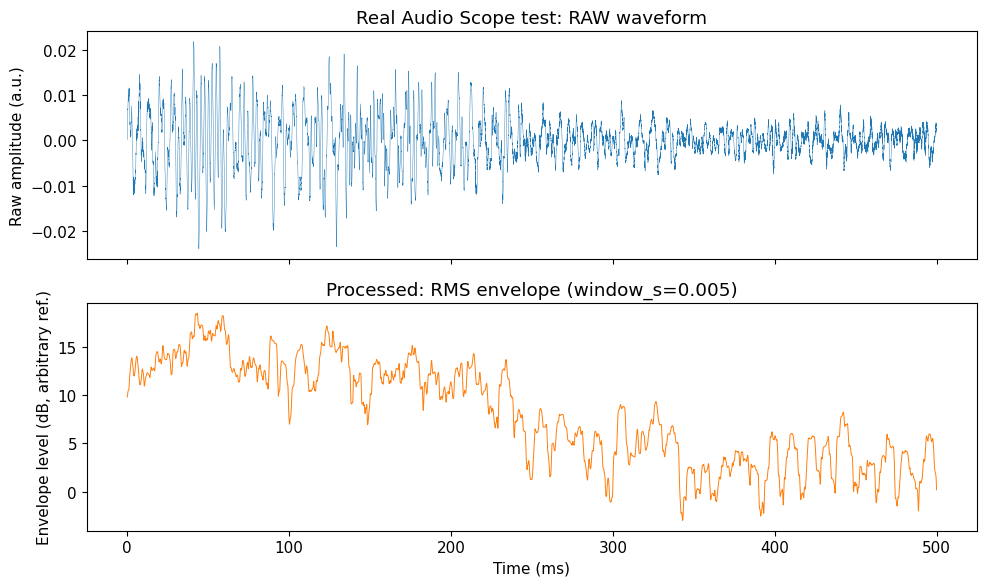

In [8]:
real_scope_path = "../data/raw/scope_noisy_one_bounce_test.xls"
real_scope_raw = io_utils.load_scope_raw(real_scope_path)
real_scope_env = io_utils.load_recording(real_scope_path, window_s=0.005)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(real_scope_raw["time_s"] * 1000, real_scope_raw["amplitude"], lw=0.3)
axes[0].set_ylabel("Raw amplitude (a.u.)")
axes[0].set_title("Real Audio Scope test: RAW waveform")

axes[1].plot(real_scope_env["time_s"] * 1000, real_scope_env["spl_db"], lw=0.7, color="C1")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Envelope level (dB, arbitrary ref.)")
axes[1].set_title("Processed: RMS envelope (window_s=0.005)")

plt.tight_layout()
plt.savefig("../figures/real_scope_raw_and_processed.png", dpi=150)
plt.show()


This recording spans only ~500 ms despite the phyphox session metadata
reporting a ~10 s duration between START and PAUSE — confirming Audio
Scope exports its rolling display buffer, not the full session.

The background noise floor here is much noisier than the quiet-room Audio
Amplitude background in Section 1 (consistent with the filename): even the
quiet region has real, sample-to-sample variability from room noise, not
just microphone self-noise. A `k_sigma=5` threshold (the Section 1 default)
sits *above* the actual bounce peak here — the signal-to-noise ratio in
this test is low, so a lower, more permissive threshold is needed to detect
anything at all, at the cost of a higher false-positive risk from ordinary
room noise.


In [9]:
peak_idx = real_scope_env["spl_db"].idxmax()
peak_t = real_scope_env["time_s"].iloc[peak_idx]
real_profile = noise.characterise_excluding_window(
    real_scope_env, exclude_center_s=peak_t, exclude_width_s=0.05, k_sigma=1.5, robust=True)
print(noise.summary_text(real_profile))
print(f"Peak level: {real_scope_env['spl_db'].max():.2f} dB "
      f"({(real_scope_env['spl_db'].max() - real_profile.mean_db) / real_profile.std_db:.1f} "
      f"sigma above the quiet-region estimate -- a weak margin.")

real_times = bd.detect_bounces_peak_picking(real_scope_env, real_profile.recommended_threshold_db,
                                             min_separation_s=0.02, prominence_db=2.0)
print(f"Detected {len(real_times)} candidate impact(s) at t = "
      f"{[round(x*1000, 1) for x in real_times]} ms")


Samples: 21601 (NaN at start: 0)
Noise floor: mean = 6.58 dB, std = 6.34 dB, median = 6.58 dB, 95th pct = 14.64 dB, max transient = 17.13 dB
Sampling interval: mean = 0.0 ms, median = 0.0 ms, std = 0.3 ms, range = [0.0, 50.0] ms
Recommended bounce-detection threshold: 16.09 dB (mean + k*std)
Peak level: 18.44 dB (1.9 sigma above the quiet-region estimate -- a weak margin.
Detected 2 candidate impact(s) at t = [43.2, 123.3] ms


**Honest assessment:** with `k_sigma=1.5` (chosen only because `k_sigma=5`
detected nothing at all in this noisy test), detection finds one or two
candidate impacts, but at this SNR a second detection cannot be trusted to
be a genuine second bounce rather than incidental room noise — and this
file's actual drop height was never recorded, since it was a detection
feasibility test, not a measurement trial. Both pieces of information (a
confirmed second impact, and a known height) are required to get *any* g
value, real or otherwise:

- $g$ needs $h_0$ directly (it appears explicitly in $g = 8h_0/A^2$).
- $g$ also needs at least one genuine $\Delta t_n$, which needs >= 2
  genuine impacts.

The cell below computes a **placeholder-only** g using an assumed height
and an assumed coefficient of restitution, purely to show the mechanical
calculation end-to-end on real audio -- flagged loudly because, per the
academic integrity requirements on this assignment, no number from this
cell should ever appear in the report as a measurement.


In [10]:
if len(real_times) >= 2:
    ASSUMED_h0 = 0.5   # PLACEHOLDER -- the real height used for this test was not logged
    ASSUMED_e = 0.8    # PLACEHOLDER -- not measured for this test
    dt1_illustrative = real_times[1] - real_times[0]
    A_illustrative = dt1_illustrative / ASSUMED_e
    g_illustrative = 8 * ASSUMED_h0 / A_illustrative**2
    print("############################################################")
    print("# ILLUSTRATIVE ONLY -- NOT A MEASUREMENT -- DO NOT CITE THIS #")
    print("############################################################")
    print(f"Using assumed h0={ASSUMED_h0} m, assumed e={ASSUMED_e}, and the "
          f"{dt1_illustrative*1000:.1f} ms interval detected above:")
    print(f"  g (placeholder calculation) = {g_illustrative:.1f} m/s^2")
    print("This is physically nonsensical, as expected: it rests on two unverified "
          "assumptions (the height, and that the second detection is a real bounce) "
          "rather than on measured quantities.")
else:
    print("Only one confirmed impact in this file -- Delta t (and therefore g) "
          "cannot be computed at all, illustratively or otherwise, without a second "
          "genuine acoustic event.")


############################################################
# ILLUSTRATIVE ONLY -- NOT A MEASUREMENT -- DO NOT CITE THIS #
############################################################
Using assumed h0=0.5 m, assumed e=0.8, and the 80.1 ms interval detected above:
  g (placeholder calculation) = 398.7 m/s^2
This is physically nonsensical, as expected: it rests on two unverified assumptions (the height, and that the second detection is a real bounce) rather than on measured quantities.


## 4. Multi-drop recordings: automatic segmentation

If several drop heights are recorded back-to-back in **one continuous**
phyphox capture (rather than starting/stopping the app between heights),
the recording must first be split into per-trial segments before
`process_trial` can be applied to each one. Segmentation works by detecting
every impulse in the whole recording and cutting a new segment wherever the
gap between consecutive impulses exceeds `min_gap_s` — i.e. wherever the
ball has clearly come to rest and the recorder is being repositioned for
the next drop.

**Protocol requirement this depends on:** leave >= 3 s of stillness between
drops when recording multiple trials in one file, so `min_gap_s` (chosen
comfortably below that, e.g. 2.5 s, and above the largest intra-trial
inter-bounce interval) cleanly separates trials without splitting a single
trial's late, closely-spaced bounces.

`process_multi_drop_recording()` (also from `src/pipeline.py`) cleans the
whole recording, segments it, and calls `process_trial()` on each segment.


### 4a. Validate segmentation against synthetic ground truth

As with the single-trial pipeline, segmentation is checked against a
synthetic multi-drop recording built from known heights in a known order
before it is trusted on a real recording.


Trimmed first 0 s and last 0 s (handling noise); dropped 0 NaN samples.
Retained 268 / 269 samples (99.6%).
Segmented into 3 usable trial(s); expected 3 (from the heights list you supplied).


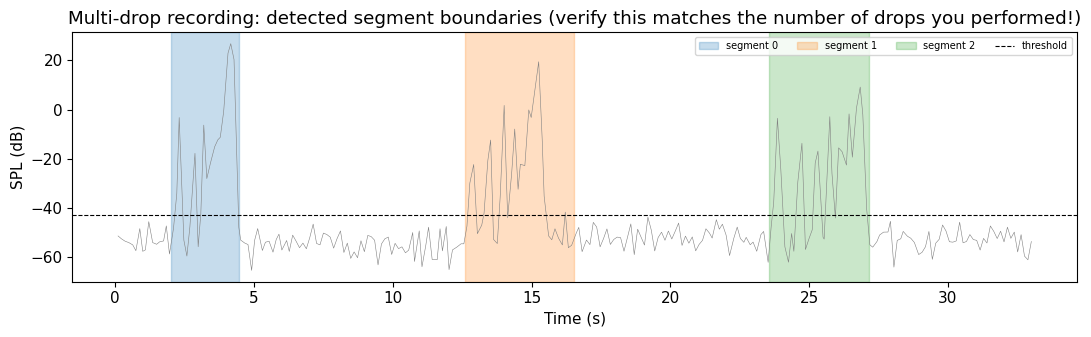

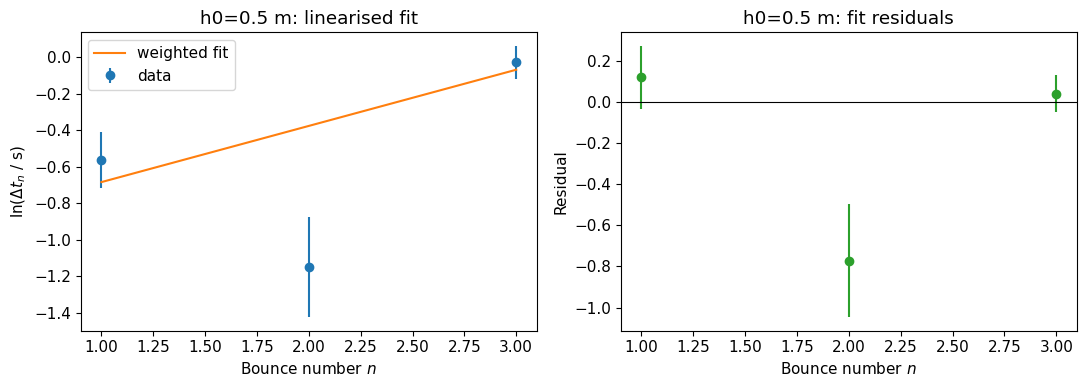

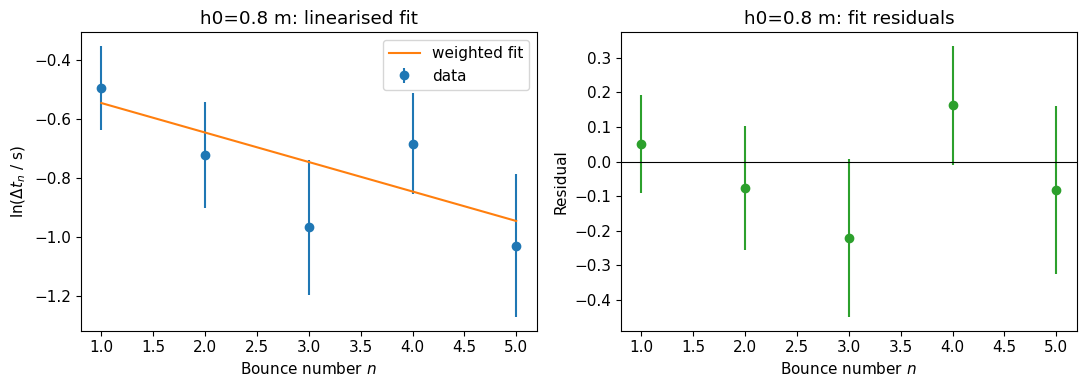

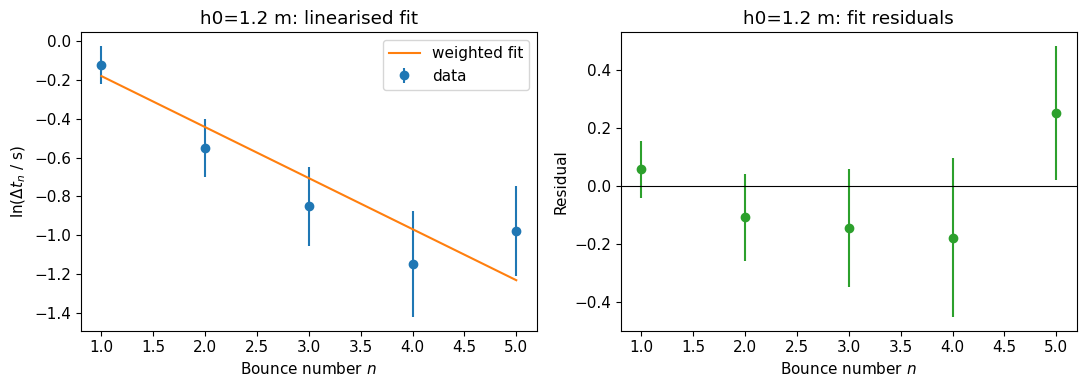

h0=0.5 m -> g = 29.0680 +/- 13.2218 m/s^2 (chi2/ndf = 8.75)
h0=0.8 m -> g = 15.5640 +/- 5.2666 m/s^2 (chi2/ndf = 0.76)
h0=1.2 m -> g = 8.1440 +/- 2.0983 m/s^2 (chi2/ndf = 0.99)
[SEGMENTATION VALIDATION] combined g = 9.5840 +/- 1.9284 m/s^2 (chi2/ndf = 1.97), true g = 9.783 m/s^2


In [11]:
# Reuse the same heights validated in Section 5 below (where max_bounce_n=5 is
# already known to keep every trial within its resolvable-bounce-count limit,
# per the Section 1 aliasing analysis). This isolates the segmentation test
# from the separate, already-documented low-height aliasing bias.
demo_heights = [0.5, 0.8, 1.2]
multi_demo = synthetic_demo.generate_multi_drop_recording(demo_heights, gap_s=4.0, seed=7)

multi_results = process_multi_drop_recording(
    multi_demo, heights=demo_heights, heights_err=[0.005] * len(demo_heights),
    threshold_db=profile.recommended_threshold_db, min_gap_s=2.5,
    trim_start_s=0.0, trim_end_s=0.0, make_plots=True,
)

for h0, res in zip(demo_heights, multi_results):
    print(f"h0={h0} m -> g = {res['g']:.4f} +/- {res['g_err']:.4f} m/s^2 "
          f"(chi2/ndf = {res['fit'].chi2_ndf:.2f})")

g_vals = np.array([r["g"] for r in multi_results])
g_errs = np.array([r["g_err"] for r in multi_results])
combo = fitting.pdg_combine(g_vals, g_errs)
print(f"[SEGMENTATION VALIDATION] combined g = {combo.g_mean:.4f} +/- {combo.g_mean_err:.4f} m/s^2 "
      f"(chi2/ndf = {combo.chi2_ndf:.2f}), true g = 9.783 m/s^2")


## 5. Pipeline validation on synthetic single-trial data (NOT a measurement)

Before trusting `process_trial` on real recordings, we validate it against
synthetic Audio Amplitude traces generated from the *known* physical model
(`synthetic_demo.generate_synthetic_trial`), so the ground-truth $g$ is
known and recovery error can be checked directly. **These are demonstration
numbers only and must not be reported as measured results.**


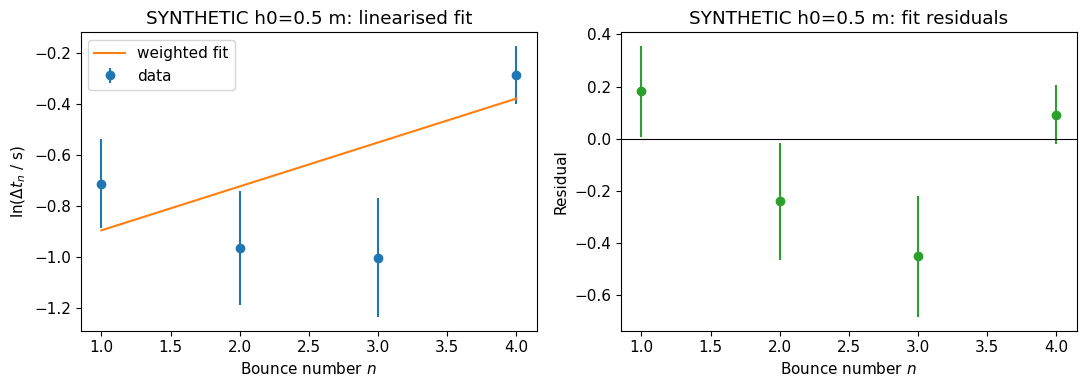

h0=0.5 m -> g = 33.7710 +/- 14.2716 m/s^2 (chi2/ndf = 3.33, peak/threshold matched: 3/5, mean offset = 68 ms)


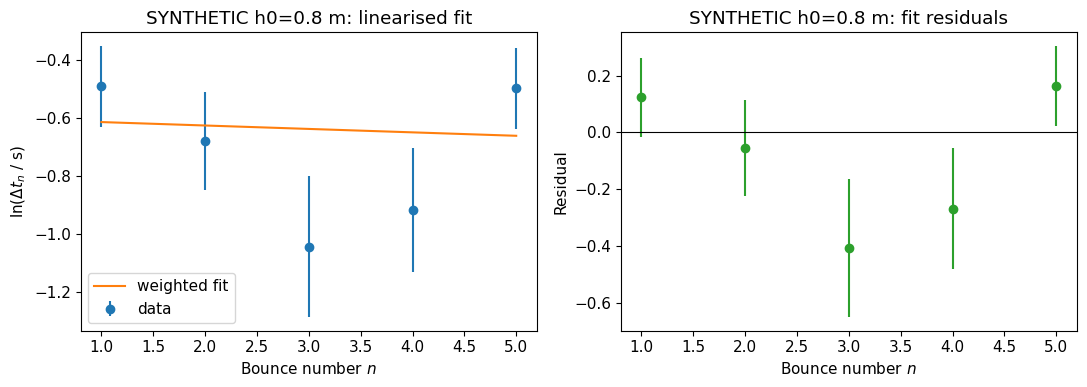

h0=0.8 m -> g = 21.3656 +/- 6.6297 m/s^2 (chi2/ndf = 2.21, peak/threshold matched: 4/6, mean offset = 92 ms)


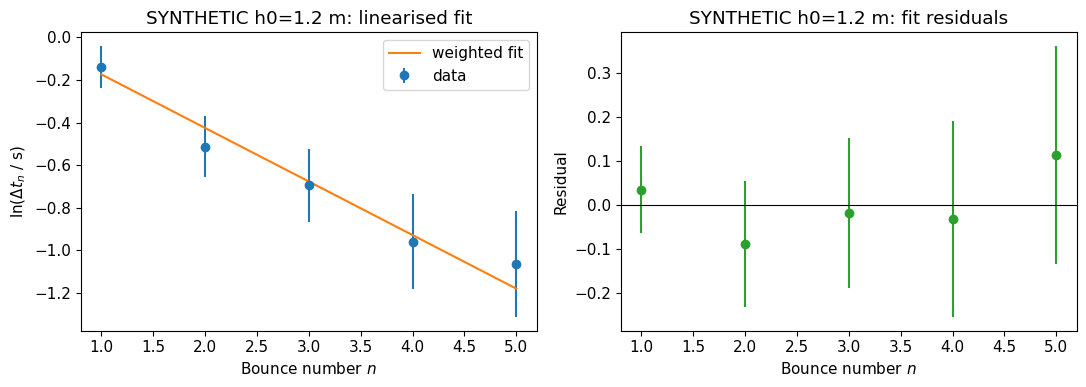

h0=1.2 m -> g = 8.2147 +/- 2.1111 m/s^2 (chi2/ndf = 0.25, peak/threshold matched: 5/8, mean offset = 68 ms)


In [12]:
synthetic_results = []
for h0 in [0.5, 0.8, 1.2]:
    df_sim = synthetic_demo.generate_synthetic_trial(h0=h0, g_true=9.783, e=0.8, seed=42)
    res = process_trial(df_sim, h0=h0, h0_err=0.005,
                         threshold_db=profile.recommended_threshold_db,
                         max_bounce_n=5, label=f"SYNTHETIC h0={h0} m")
    synthetic_results.append(res)
    ag = res["agreement"]
    print(f"h0={h0} m -> g = {res['g']:.4f} +/- {res['g_err']:.4f} m/s^2 "
          f"(chi2/ndf = {res['fit'].chi2_ndf:.2f}, peak/threshold matched: "
          f"{ag['n_matched']}/{ag['n_a']}, mean offset = {ag['mean_offset_s']*1000:.0f} ms)")


In [13]:
g_vals = np.array([r["g"] for r in synthetic_results])
g_errs = np.array([r["g_err"] for r in synthetic_results])
combo = fitting.pdg_combine(g_vals, g_errs)
print(f"[SYNTHETIC VALIDATION] combined g = {combo.g_mean:.4f} +/- {combo.g_mean_err:.4f} m/s^2 "
      f"(chi2/ndf = {combo.chi2_ndf:.2f}), true g = 9.783 m/s^2")


[SYNTHETIC VALIDATION] combined g = 9.8996 +/- 1.9919 m/s^2 (chi2/ndf = 3.21), true g = 9.783 m/s^2


## 6. Real trial data — template

Once real drop-trial recordings are collected (>= 5 heights from 0.3 m to
1.5 m as required), use **one** of the two workflows below depending on how
you recorded them, then fill in the height/uncertainty values. Re-run this
section; delete the synthetic-validation sections before final submission
or keep them clearly marked as a validation appendix.

**Workflow A — one phyphox file per height** (start/stop the app between
drops): use the loop below.

**Workflow B — all heights in one continuous recording**: use
`process_multi_drop_recording` instead (see the commented block), giving
the heights in the exact chronological order you dropped them.

Both workflows accept either Audio Amplitude or Audio Scope exports —
just point `io_utils.load_recording(...)` at the file (add `kind="scope"`
if auto-detection doesn't find the right columns).


In [14]:
# --- Workflow A: one file per height. Fill in once real data is collected. ---
trial_files = {
    # "height_030.xls": (0.30, 0.005),   # (h0 in m, h0_err in m)
    # "height_050.xls": (0.50, 0.005),
    # "height_080.xls": (0.80, 0.005),
    # "height_120.xls": (1.20, 0.005),
    # "height_150.xls": (1.50, 0.005),
}

real_results = []
for fname, (h0, h0_err) in trial_files.items():
    df_trial = io_utils.load_recording(f"../data/raw/{fname}")
    res = process_trial(df_trial, h0=h0, h0_err=h0_err,
                         threshold_db=profile.recommended_threshold_db,
                         max_bounce_n=6, label=fname)
    real_results.append(res)
    print(f"{fname}: g = {res['g']:.4f} +/- {res['g_err']:.4f} m/s^2 "
          f"(chi2/ndf = {res['fit'].chi2_ndf:.2f})")

# --- Workflow B: all heights in one continuous recording. Uncomment and fill in. ---
# heights = [0.30, 0.50, 0.80, 1.20, 1.50]            # chronological drop order
# heights_err = [0.005] * len(heights)
# df_multi = io_utils.load_recording("../data/raw/all_heights.xls")
# real_results = process_multi_drop_recording(
#     df_multi, heights=heights, heights_err=heights_err,
#     threshold_db=profile.recommended_threshold_db, min_gap_s=2.5,
# )

if real_results:
    g_vals = np.array([r["g"] for r in real_results])
    g_errs = np.array([r["g_err"] for r in real_results])
    combo = fitting.pdg_combine(g_vals, g_errs)
    g_ref = 9.783
    pull = fitting.pull(combo.g_mean, combo.g_mean_err, g_ref)
    print(f"Combined g = {combo.g_mean:.4f} +/- {combo.g_mean_err:.4f} m/s^2, "
          f"chi2/ndf = {combo.chi2_ndf:.2f}, pull vs g_ref = {pull:.2f} sigma")


## 7. Uncertainty budget (template)

| Source | Type | Est. magnitude | Notes |
|---|---|---|---|
| Bounce-timing quantisation (sample interval / 2) | Statistical | ~half of `median_dt_s` above | Propagated through $\Delta t_n$ into the fit |
| Height measurement ($h_0$) | Statistical | ruler/tape precision, e.g. ±5 mm | Propagated into $g$ via $\partial g/\partial h_0$ |
| Fit parameter uncertainty (intercept) | Statistical | from weighted LS covariance | Dominates if few bounces are usable |
| Non-constant coefficient of restitution | Systematic | assess via residual curvature | Real balls: $e$ decreases slightly with impact speed |
| Peak-detection threshold choice | Systematic | vary threshold ±2σ, refit | Reported as spread in $g$ across threshold choices |
| Microphone/audio buffering latency | Systematic | phone-model dependent, typically <10 ms | Partly cancels in *interval* differences, does not fully cancel |
| Ball spin / off-axis bouncing | Systematic | qualitative, hard to quantify directly | Discuss, do not double count with restitution term |
| Surface hardness / local deformation | Systematic | check for trend vs. drop height | Would show up as height-dependent bias in $g_i$ |

Fill in actual magnitudes once real data is available; this table is a
starting structure, not a substitute for computing each entry from your own
trials.
